In [11]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("OK")

OK


In [12]:
train = pd.read_csv('../data/application_train.csv')

print(f"Строк:   {train.shape[0]:,}")
print(f"Колонок: {train.shape[1]}")
train.head()

Строк:   307,511
Колонок: 122


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,...,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0000,406597.5000,24700.5000,351000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0188,-9461,-637,-3648.0000,-2120,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
1,100003,0,Cash loans,F,N,N,0,270000.0000,1293502.5000,35698.5000,1129500.0000,Family,State servant,Higher education,Married,House / apartment,0.0035,-16765,-1188,-1186.0000,-291,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,100004,0,Revolving loans,M,Y,Y,0,67500.0000,135000.0000,6750.0000,135000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0100,-19046,-225,-4260.0000,-2531,26.0000,1,1,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,100006,0,Cash loans,F,N,Y,0,135000.0000,312682.5000,29686.5000,297000.0000,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.0080,-19005,-3039,-9833.0000,-2437,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0000,513000.0000,21865.5000,513000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0287,-19932,-3038,-4311.0000,-3458,NaN,1,1,0,...,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [13]:
print(train.dtypes.value_counts())
print(f"\nЧисловых:    {train.select_dtypes(include=np.number).shape[1]}")
print(f"Текстовых:   {train.select_dtypes(include=object).shape[1]}")

float64    65
int64      41
str        16
Name: count, dtype: int64

Числовых:    106
Текстовых:   16


Класс 0 (не дефолт): 282,686  (91.93%)
Класс 1 (дефолт):     24,825  (8.07%)


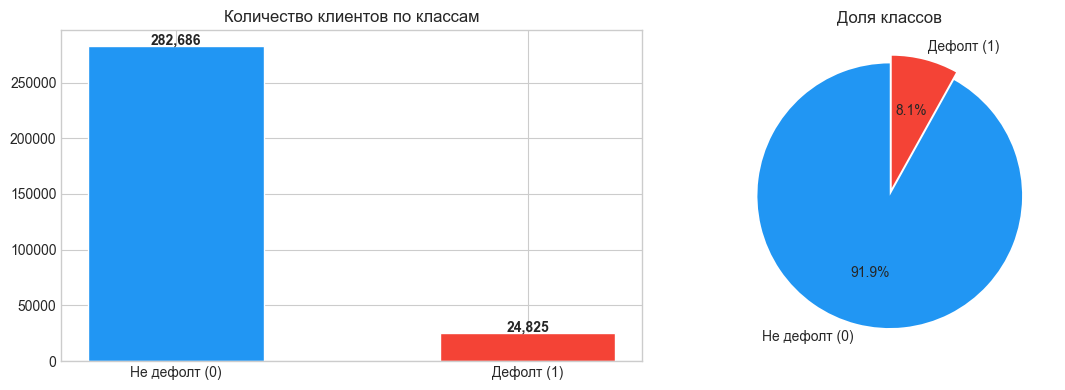

In [14]:
counts = train['TARGET'].value_counts()
pct    = train['TARGET'].value_counts(normalize=True) * 100

print(f"Класс 0 (не дефолт): {counts[0]:>7,}  ({pct[0]:.2f}%)")
print(f"Класс 1 (дефолт):    {counts[1]:>7,}  ({pct[1]:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#2196F3', '#F44336']

bars = axes[0].bar(['Не дефолт (0)', 'Дефолт (1)'], counts, color=colors, edgecolor='white', width=0.5)
for bar, value in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500, f'{value:,}', ha='center', fontweight='bold')
axes[0].set_title('Количество клиентов по классам')

axes[1].pie(counts, labels=['Не дефолт (0)', 'Дефолт (1)'], colors=colors, autopct='%1.1f%%', startangle=90, explode=(0, 0.06))
axes[1].set_title('Доля классов')

plt.tight_layout()
plt.savefig('../reports/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Колонок с пропусками: 67 из 122


,Пропусков,Процент (%)
COMMONAREA_MEDI,214865,69.8700
COMMONAREA_MODE,214865,69.8700
COMMONAREA_AVG,214865,69.8700
NONLIVINGAPARTMENTS_MODE,213514,69.4300
NONLIVINGAPARTMENTS_MEDI,213514,69.4300
NONLIVINGAPARTMENTS_AVG,213514,69.4300
FONDKAPREMONT_MODE,210295,68.3900
LIVINGAPARTMENTS_AVG,210199,68.3500
LIVINGAPARTMENTS_MEDI,210199,68.3500
LIVINGAPARTMENTS_MODE,210199,68.3500


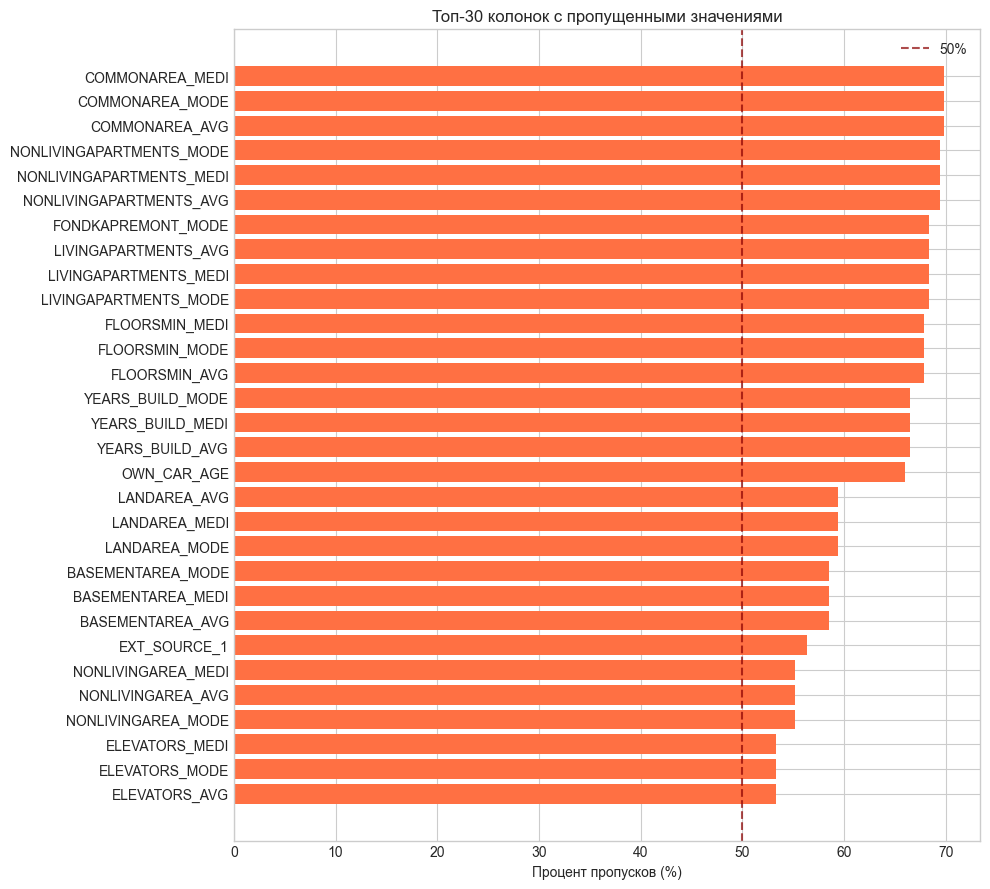

In [15]:
missing = pd.DataFrame({
    'Пропусков':   train.isnull().sum(),
    'Процент (%)': (train.isnull().sum() / len(train) * 100).round(2)
})
missing = missing[missing['Пропусков'] > 0].sort_values('Процент (%)', ascending=False)

print(f"Колонок с пропусками: {len(missing)} из {train.shape[1]}")
display(missing.head(20))

fig, ax = plt.subplots(figsize=(10, 9))
top30 = missing.head(30)
ax.barh(top30.index[::-1], top30['Процент (%)'][::-1], color='#FF7043')
ax.axvline(x=50, color='darkred', linestyle='--', alpha=0.7, label='50%')
ax.set_xlabel('Процент пропусков (%)')
ax.set_title('Топ-30 колонок с пропущенными значениями')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/01_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
anomaly_mask  = (train['DAYS_EMPLOYED'] == 365243)
rate_anomaly  = train.loc[anomaly_mask,  'TARGET'].mean() * 100
rate_normal   = train.loc[~anomaly_mask, 'TARGET'].mean() * 100

print(f"Клиентов с аномалией: {anomaly_mask.sum():,} ({anomaly_mask.mean()*100:.1f}%)")
print(f"Дефолты (аномальные): {rate_anomaly:.2f}%")
print(f"Дефолты (нормальные): {rate_normal:.2f}%")
print("Решение: создать флаг IS_UNEMPLOYED, заменить 365243 на NaN")

Клиентов с аномалией: 55,374 (18.0%)
Дефолты (аномальные): 5.40%
Дефолты (нормальные): 8.66%
Решение: создать флаг IS_UNEMPLOYED, заменить 365243 на NaN


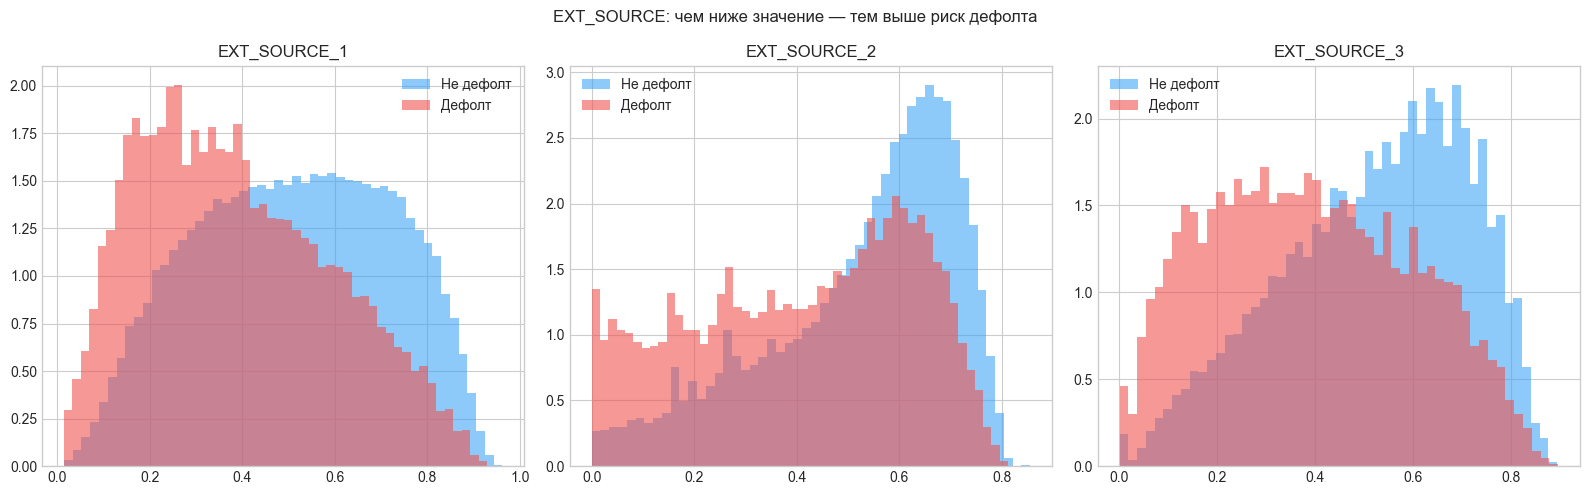

  EXT_SOURCE_1: corr=-0.1553  пропусков=56.4%
  EXT_SOURCE_2: corr=-0.1605  пропусков=0.2%
  EXT_SOURCE_3: corr=-0.1789  пропусков=19.8%


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    for target_val, color, label in [(0, '#42A5F5', 'Не дефолт'), (1, '#EF5350', 'Дефолт')]:
        data = train[train['TARGET'] == target_val][col].dropna()
        axes[i].hist(data, bins=50, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(col)
    axes[i].legend()

plt.suptitle('EXT_SOURCE: чем ниже значение — тем выше риск дефолта')
plt.tight_layout()
plt.savefig('../reports/01_ext_source.png', dpi=150, bbox_inches='tight')
plt.show()

for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
    corr = train[col].corr(train['TARGET'])
    pct  = train[col].isnull().mean() * 100
    print(f"  {col}: corr={corr:.4f}  пропусков={pct:.1f}%")

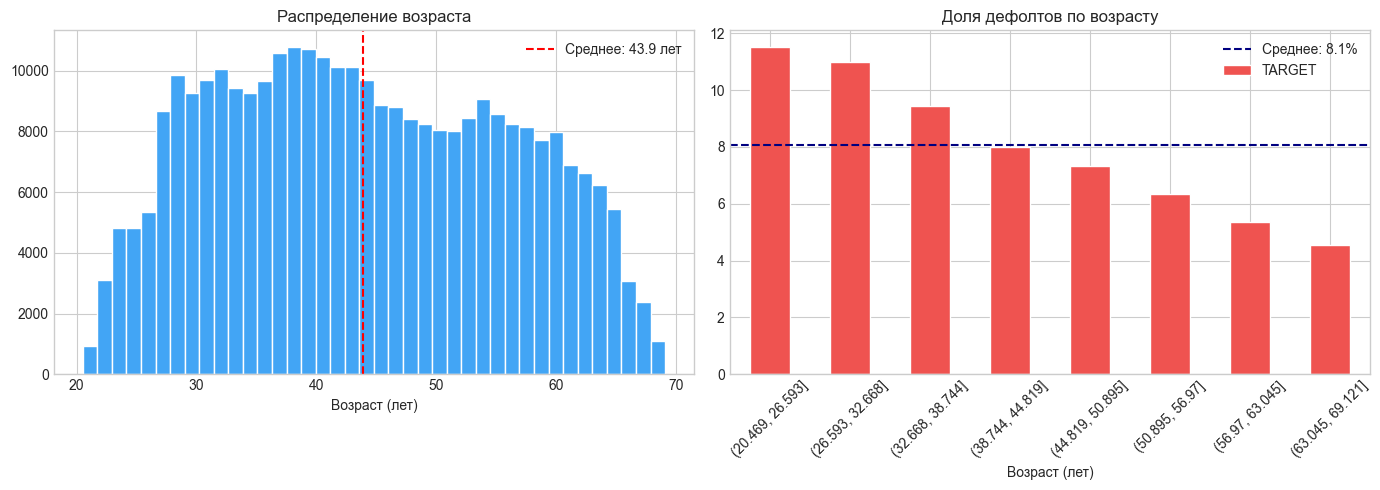

In [18]:
age_years = -train['DAYS_BIRTH'] / 365

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(age_years, bins=40, color='#42A5F5', edgecolor='white')
axes[0].axvline(age_years.mean(), color='red', linestyle='--', label=f'Среднее: {age_years.mean():.1f} лет')
axes[0].set_title('Распределение возраста')
axes[0].set_xlabel('Возраст (лет)')
axes[0].legend()

default_rate = train.groupby(pd.cut(age_years, bins=8), observed=True)['TARGET'].mean() * 100
default_rate.plot(kind='bar', ax=axes[1], color='#EF5350', edgecolor='white')
axes[1].axhline(y=train['TARGET'].mean()*100, color='navy', linestyle='--', label=f'Среднее: {train["TARGET"].mean()*100:.1f}%')
axes[1].set_title('Доля дефолтов по возрасту')
axes[1].set_xlabel('Возраст (лет)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/01_age_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
num_cols = [c for c in train.select_dtypes(include=np.number).columns if c not in ['SK_ID_CURR', 'TARGET']]
correlations = train[num_cols].corrwith(train['TARGET']).dropna().abs().sort_values(ascending=False)

print("Топ-20 признаков по корреляции с TARGET:")
for rank, (col, corr) in enumerate(correlations.head(20).items(), 1):
    print(f"  {rank:>2}. {col:<45} {corr:.4f}  {'█' * int(corr * 50)}")

Топ-20 признаков по корреляции с TARGET:
   1. EXT_SOURCE_3                                  0.1789  ████████
   2. EXT_SOURCE_2                                  0.1605  ████████
   3. EXT_SOURCE_1                                  0.1553  ███████
   4. DAYS_BIRTH                                    0.0782  ███
   5. REGION_RATING_CLIENT_W_CITY                   0.0609  ███
   6. REGION_RATING_CLIENT                          0.0589  ██
   7. DAYS_LAST_PHONE_CHANGE                        0.0552  ██
   8. DAYS_ID_PUBLISH                               0.0515  ██
   9. REG_CITY_NOT_WORK_CITY                        0.0510  ██
  10. FLAG_EMP_PHONE                                0.0460  ██
  11. DAYS_EMPLOYED                                 0.0449  ██
  12. REG_CITY_NOT_LIVE_CITY                        0.0444  ██
  13. FLAG_DOCUMENT_3                               0.0443  ██
  14. FLOORSMAX_AVG                                 0.0440  ██
  15. FLOORSMAX_MEDI                                0.0438

In [20]:
table_files = {
    'bureau':              '../data/bureau.csv',
    'bureau_balance':      '../data/bureau_balance.csv',
    'previous_application':'../data/previous_application.csv',
    'POS_CASH_balance':    '../data/POS_CASH_balance.csv',
    'installments':        '../data/installments_payments.csv',
    'credit_card':         '../data/credit_card_balance.csv',
}

print(f"{'Таблица':<25} {'Строк':>12}  {'Колонок':>8}")
print("-" * 50)
for name, path in table_files.items():
    df = pd.read_csv(path, nrows=5000)
    print(f"{name:<25} {'(первые 5k)':>12}  {df.shape[1]:>8}")

Таблица                          Строк   Колонок
--------------------------------------------------
bureau                     (первые 5k)        17
bureau_balance             (первые 5k)         3
previous_application       (первые 5k)        37
POS_CASH_balance           (первые 5k)         8
installments               (первые 5k)         8
credit_card                (первые 5k)        23
